In [33]:
import pandas as pd
import numpy as np 
import warnings
warnings.filterwarnings("ignore")
df = pd.read_excel("Bajaj_Finance_Loan_Dataset Sample.xlsx")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nPD Distribution:")
print(df["PD"].value_counts())
print(f"\nDefault Rate: {df['PD'].mean():.2%}")
print("\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Rows: 1000, Columns: 49

PD Distribution:
PD
0    539
1    461
Name: count, dtype: int64

Default Rate: 46.10%

Missing Values:
Product 2       571
Product 3       908
Unnamed: 43    1000
Unnamed: 44    1000
Unnamed: 45    1000
Unnamed: 46    1000
Unnamed: 47     986
Unnamed: 48     986
dtype: int64


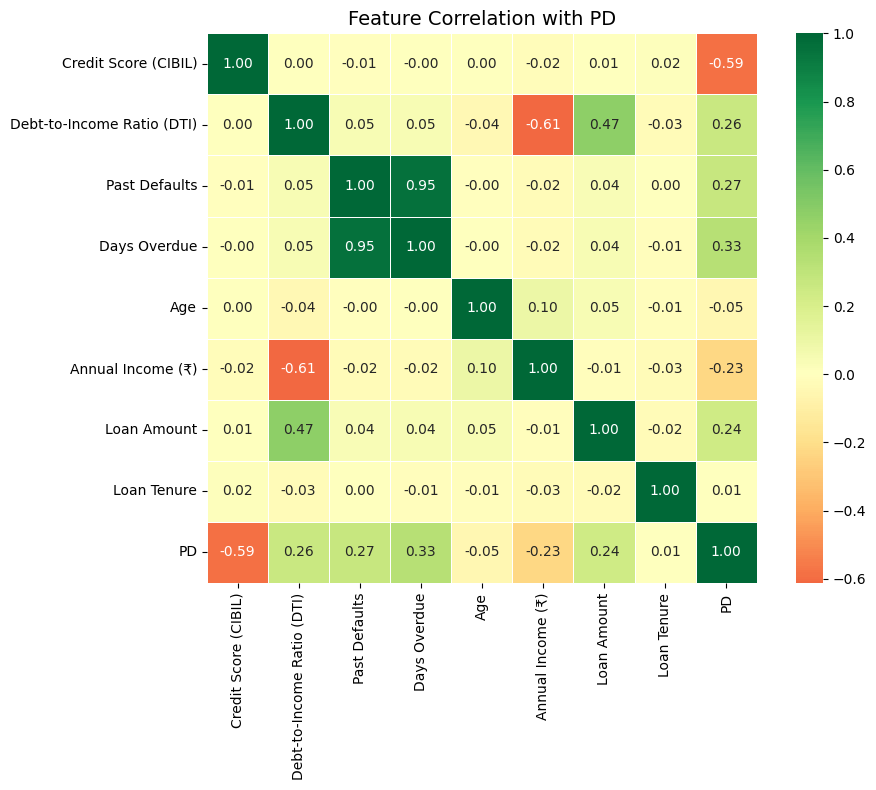

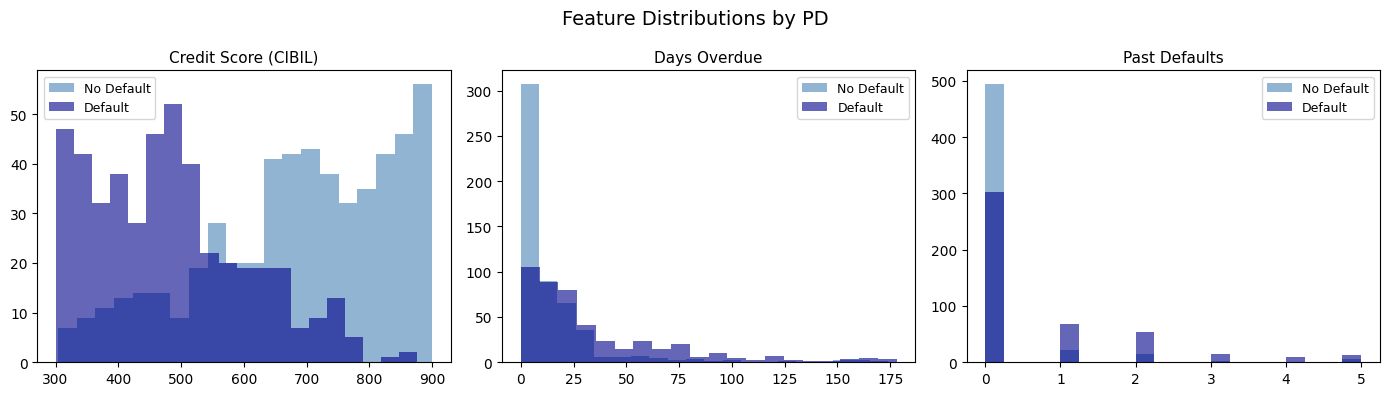

Correlation with PD (Strongest First):
Credit Score (CIBIL)         -0.591800
Annual Income (₹)            -0.227852
Age                          -0.049044
Loan Tenure                   0.006685
Loan Amount                   0.237118
Debt-to-Income Ratio (DTI)    0.259422
Past Defaults                 0.273729
Days Overdue                  0.326593
Name: PD, dtype: float64


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
raw_features = [
    'Credit Score (CIBIL)', 'Debt-to-Income Ratio (DTI)',
    'Past Defaults', 'Days Overdue', 'Age', 
    'Annual Income (₹)', 'Loan Amount', 'Loan Tenure', 'PD'
]
plt.figure(figsize=(10,8))
sns.heatmap(df[raw_features].corr(), annot=True,fmt='.2f', cmap='RdYlGn', center=0, linewidth=0.5, square=True
)
plt.title('Feature Correlation with PD', fontsize=14)
plt.tight_layout()
plt.show()
fig,axes = plt.subplots(1, 3, figsize=(14, 4))
no_def = df[df['PD'] == 0]
default = df[df['PD'] == 1]
for ax,col in zip(axes, ['Credit Score (CIBIL)', 'Days Overdue', 'Past Defaults']):
    ax.hist(no_def[col], bins=20, alpha=0.6, label='No Default', color='steelblue')
    ax.hist(default[col], bins=20, alpha=0.6, label='Default', color='darkblue')
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=9)
    plt.suptitle('Feature Distributions by PD', fontsize=14)
plt.tight_layout()
plt.show()

print("Correlation with PD (Strongest First):")
print(df[raw_features].corr()['PD'].drop('PD').sort_values())


In [35]:
df['employment_encoded'] = (df['Employment Type'] == 'Salaried').astype(int)
repayment_map = {
    'PAID': 0,
    'DELAYED': 1,
    '1 MONTH DELAYED': 2,
    '2 MONTHS DELAYED': 3,
    '3 MONTHS DELAYED': 4,
    '4 MONTHS DELAYED': 5,
    '5 MONTHS DELAYED': 6,
}
df['repayment_encoded'] = df['Repayment History'].map(repayment_map).fillna(1)
df['product_count'] = (
    df['Product 1'].notna().astype(int) +
    df['Product 2'].notna().astype(int) +
    df['Product 3'].notna().astype(int)
)
df['emi_to_income'] = df['Total EMI / Month (₹)'] / (df['Annual Income (₹)'] / 12)
df['loan_to_income'] = df['Loan Amount'] / df['Annual Income (₹)']

feature_cols = [
    'Credit Score (CIBIL)',
    'Debt-to-Income Ratio (DTI)',
    'Past Defaults',
    'Days Overdue',
    'Age',
    'Annual Income (₹)',
    'Loan Amount',
    'Loan Tenure',
    'Total EMI / Month (₹)',
    'employment_encoded',
    'repayment_encoded',
    'product_count',
    'emi_to_income',
    'loan_to_income'
]
X = df[feature_cols].copy()
Y = df['PD'].copy()

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape : {Y.shape}")
print(f"Nulls in X : {X.isnull().sum().sum()}")
print("\nFeatures used:")
for i, f in enumerate(feature_cols, 1):
    print(f"{i:02d}. {f}")


Feature matrix shape : (1000, 14)
Target vector shape : (1000,)
Nulls in X : 0

Features used:
01. Credit Score (CIBIL)
02. Debt-to-Income Ratio (DTI)
03. Past Defaults
04. Days Overdue
05. Age
06. Annual Income (₹)
07. Loan Amount
08. Loan Tenure
09. Total EMI / Month (₹)
10. employment_encoded
11. repayment_encoded
12. product_count
13. emi_to_income
14. loan_to_income


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.30,
    random_state=42,
    stratify=Y
)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)
print(f"Training set : {X_train.shape[0]} rows")
print(f"Test set : {X_test.shape[0]} rows")
print(f"Train PD rate : {Y_train.mean() :.2%}")
print(f"Test PD rate : {Y_test.mean() :.2%}")
print("\nBoth PD rates should be around 46% - confirm stratifiction worked")

Training set : 700 rows
Test set : 300 rows
Train PD rate : 46.14%
Test PD rate : 46.00%

Both PD rates should be around 46% - confirm stratifiction worked


LogisticRegression AUC-ROC : 0.9685

              precision    recall  f1-score   support

  No Default       0.91      0.91      0.91       162
     Default       0.89      0.89      0.89       138

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300


Feature Coefficients (positive = increases PD risk)
                   Feature  Coefficient
      Credit Score (CIBIL)    -3.231353
             Past Defaults    -1.257055
         Annual Income (₹)    -1.158943
             emi_to_income    -0.424015
                       Age    -0.151486
        employment_encoded     0.102360
             product_count     0.140278
               Loan Tenure     0.169697
     Total EMI / Month (₹)     0.348489
            loan_to_income     0.421963
Debt-to-Income Ratio (DTI)     0.421963
         repayment_encoded     0.700986
               Loan Amount     0.885053
              Days Over

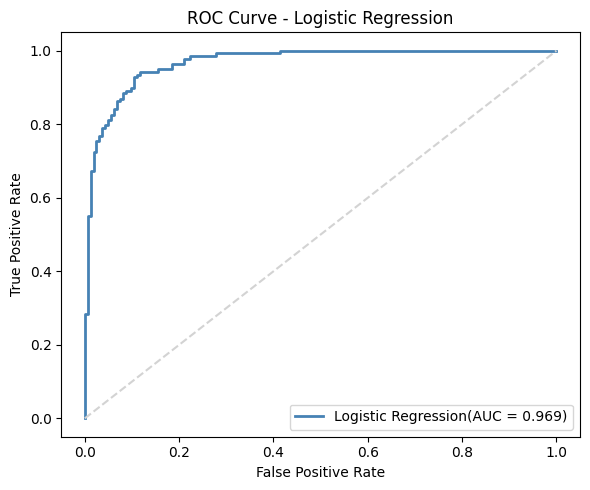

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
lr_model = LogisticRegression(random_state=42, max_iter=500, C=1.0)
lr_model.fit(X_train_scaled, Y_train)
lr_probs = lr_model.predict_proba(X_test_scaled)[: ,1]
lr_auc = roc_auc_score(Y_test, lr_probs)
print(f"LogisticRegression AUC-ROC : {lr_auc:.4f}")
print()
print(classification_report(Y_test, lr_model.predict(X_test_scaled),
                            target_names=['No Default', 'Default']))
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]  
}).sort_values('Coefficient')
print("\nFeature Coefficients (positive = increases PD risk)")
print(coef_df.to_string(index=False))
fpr_lr, tpr_lr, _ = roc_curve(Y_test, lr_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, color='steelblue', lw=2,
         label=f'Logistic Regression(AUC = {lr_auc:.3f})')
plt.plot([0, 1], [0, 1], '--', color='lightgray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

XGBoost AUC-ROC : 0.9924
Logistic AUC-ROC : 0.9685
Improvement : +0.0239

              precision    recall  f1-score   support

  No Default       0.98      0.98      0.98       162
     Default       0.98      0.98      0.98       138

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



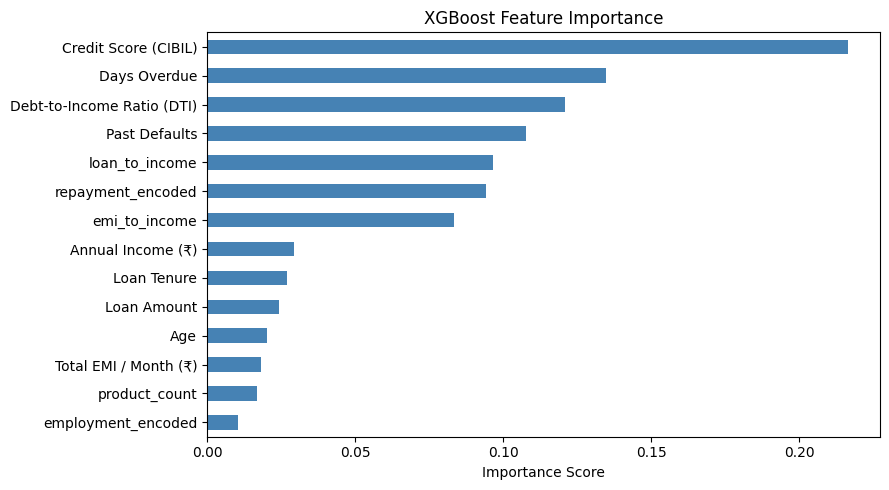

In [38]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=42,
    verbosity=0
)
xgb_model.fit(
    X_train, Y_train,
    eval_set=[(X_test, Y_test)],
    verbose=False
)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(Y_test, xgb_probs)
print(f"XGBoost AUC-ROC : {xgb_auc:.4f}")
print(f"Logistic AUC-ROC : {lr_auc:.4f}")
print(f"Improvement : +{(xgb_auc - lr_auc):.4f}")
print()
print(classification_report(Y_test, xgb_model.predict(X_test),
                            target_names=['No Default', 'Default']))
feat_imp = pd.Series(xgb_model.feature_importances_, index =feature_cols)
feat_imp.sort_values().plot(
    kind='barh', figsize=(9, 5),
    title='XGBoost Feature Importance',
    
    color='steelblue'
)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

  CREDIT RISK MODEL SCORECARD
 AUC_ROC : 0.9924 target > 0.75
 Gini : 0.9849 target > 0.50
 KS Stat : 0.9681 target > 0.30
 AUC-ROC > 0.75 : PASS
 Gini > 0.50 : PASS
 KS > 0.30 : PASS


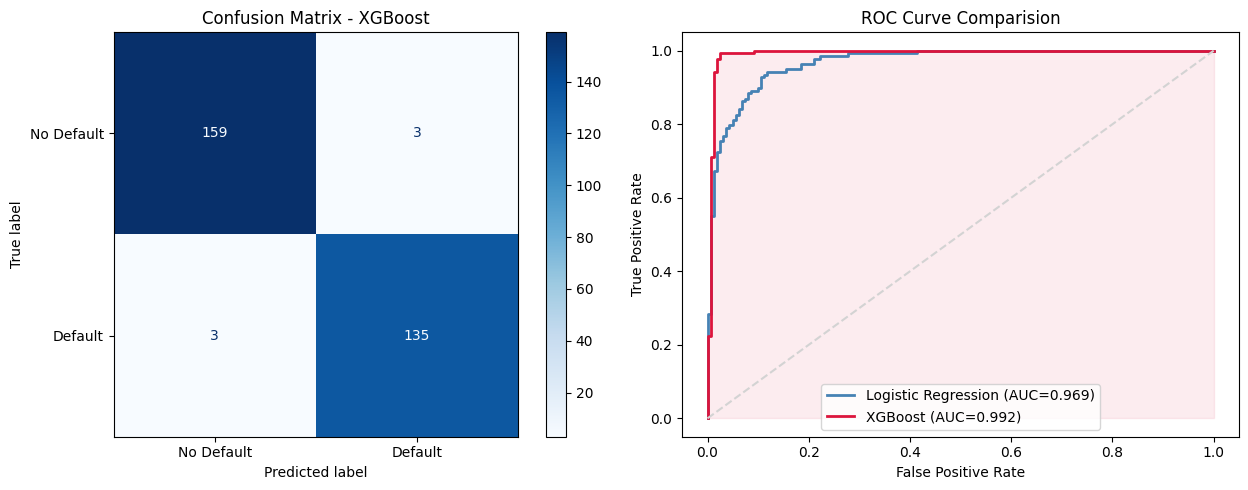

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay
auc= roc_auc_score(Y_test, xgb_probs)
gini = 2 *auc - 1
fpr, tpr, thresholds = roc_curve(Y_test, xgb_probs)
ks_stat = np.max(tpr - fpr)
print("=" * 40)
print("  CREDIT RISK MODEL SCORECARD")
print(f" AUC_ROC : {auc:.4f} target > 0.75")
print(f" Gini : {gini:.4f} target > 0.50")
print(f" KS Stat : {ks_stat:.4f} target > 0.30")
print("=" * 40)
checks = {
    'AUC-ROC > 0.75' : auc > 0.75,
    'Gini > 0.50' : gini > 0.50,
    'KS > 0.30' : ks_stat > 0.30
}

for check, passed in checks.items() :
    status = "PASS" if passed else "FAIL - Needs Tuning"
    print(f" {check} : {status}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_estimator(
    xgb_model, X_test, Y_test,
    display_labels=['No Default', 'Default'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix - XGBoost')
fpr_lr2, tpr_lr2, _ = roc_curve(Y_test, lr_probs)
axes[1].plot(fpr_lr2, tpr_lr2, color='steelblue' , lw=2,
             label=f'Logistic Regression (AUC={lr_auc:.3f})')
axes[1].plot(fpr, tpr, color='crimson', lw=2,
             label=f'XGBoost (AUC={auc:.3f})')
axes[1].fill_between(fpr, tpr, alpha=0.08, color='crimson')
axes[1].plot([0, 1], [0, 1], '--', color='lightgray')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparision')
axes[1].legend()
plt.tight_layout()
plt.show()


In [40]:
feat_imp = pd.Series(xgb_model.feature_importances_, index=feature_cols)
if feat_imp.max() > 0.60 :
    print("\nData Leakage")
else :
    print("\nCrazy Model-No Leakage")



Crazy Model-No Leakage


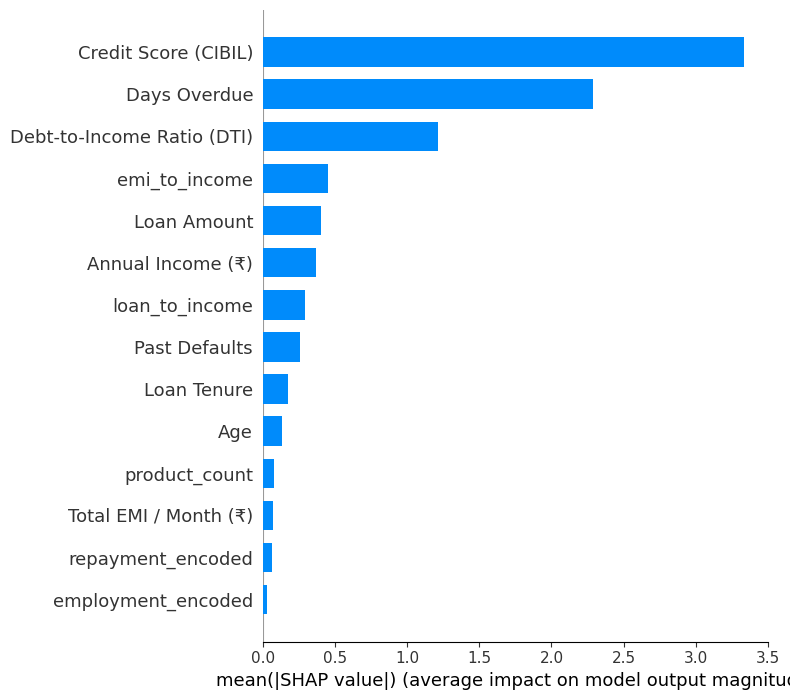

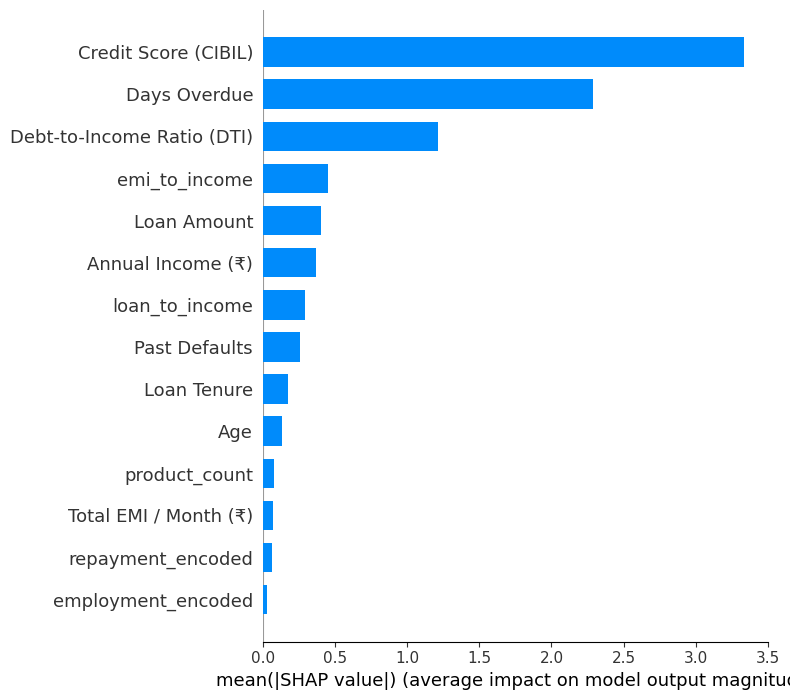

Customer at index 10 :
Credit Score (CIBIL)             738.000000
Debt-to-Income Ratio (DTI)         1.143958
Past Defaults                      0.000000
Days Overdue                       0.000000
Age                               59.000000
Annual Income (₹)             549502.000000
Loan Amount                   628607.000000
Loan Tenure                       84.000000
Total EMI / Month (₹)           5754.250000
employment_encoded                 1.000000
repayment_encoded                  0.000000
product_count                      1.000000
emi_to_income                      0.125661
loan_to_income                     1.143958
Name: 569, dtype: float64

Predicted PD : 0.11%
Actual PD : No Default


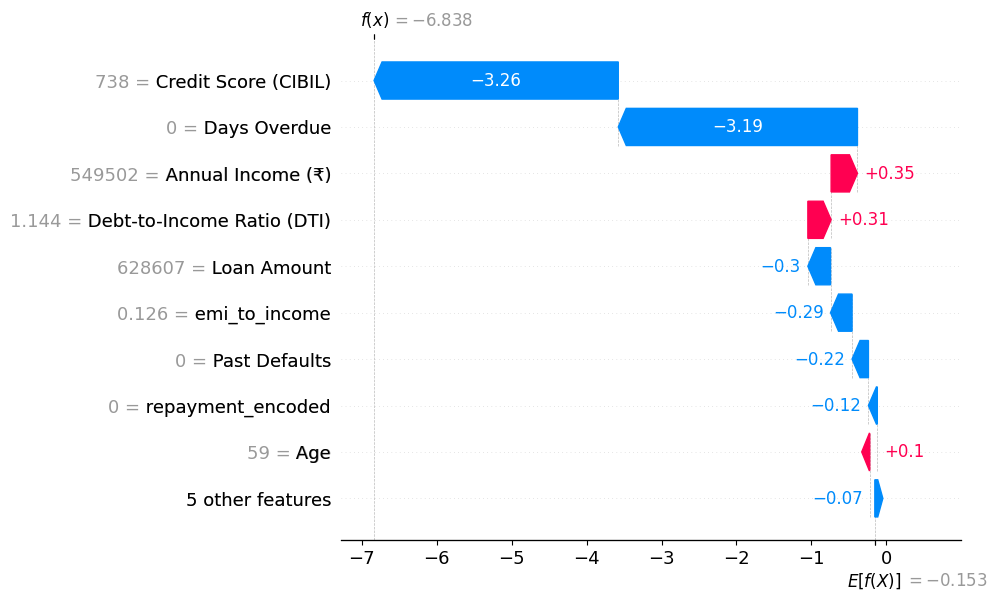

In [41]:
import shap
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=feature_cols,
                  plot_type='bar', show=True)
# use the newer SHAP API to get an Explanation object and values
shap_expl = explainer(X_test)
shap_values = shap_expl.values
explainer_expected_value = shap_expl.base_values
shap.summary_plot(shap_expl, X_test, feature_names=feature_cols, plot_type='bar', show=True)
customer_idx = 10
print(f"Customer at index {customer_idx} :")
print(X_test.iloc[customer_idx])
print(f"\nPredicted PD : {xgb_probs[customer_idx] :.2%}")
print(f"Actual PD : {'Default' if Y_test.iloc[customer_idx] == 1 else 'No Default'}")
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[customer_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[customer_idx].values,
        feature_names=feature_cols
    )
)

In [42]:
def assign_tier(pd_prob):
    if pd_prob < 0.15: return 'Low Risk'
    elif pd_prob < 0.40: return 'Watch'
    elif pd_prob < 0.70: return 'High Risk'
    else : return 'Critical / NPA Risk'
    
all_probs = xgb_model.predict_proba(X)[:, 1]
all_shap = explainer.shap_values(X)

def top_factors(shap_row, feat_names, n=3):
    idx = np.argsort(np.abs(shap_row))[::-1][:n]
    return ', '.join([feat_names[i] for i in idx])
output_df = pd.DataFrame({
    'LAN' : df['LAN'],
    'Customer Name' : df['Customer Name'],
    'PD_Probability' : np.round(all_probs, 4),
    'Risk_Tier' : [assign_tier(p) for p in all_probs],
    'Actual PD' : df['PD'],
    'Top_Risk_Factors' : [top_factors(all_shap[i], feature_cols) for i in range(len(df))],
    'Collection_Action' : pd.cut(
        all_probs,
        bins=[0, 0.15, 0.40, 0.70, 1.0],
        labels=['SMS nudge', 'IVR outbound call',
                'Priority Agent Call', 'Field Visit / Legal'])
                          })


In [43]:
import joblib
xgb_model.save_model('xgb_credit_model.json')
joblib.dump(scaler,  'feature_scaler.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')
print("Saved")
print(" xgb_credit_model.json")
print(" feature_scaler.pkl")
print(" feature_cols.pkl")

Saved
 xgb_credit_model.json
 feature_scaler.pkl
 feature_cols.pkl


In [44]:
import pandas as pd
import numpy as np
import os
np.random.seed(42)
N = 1000
customer_ids = [f"BFL{str(i).zfill(5)}" for i in range(1, N + 1)]
names = [f"Customer_{i}" for i in range(1, 1 + N)]
loan_types = np.random.choice(
    ["Personal Loan", "Consumer Durable", "Auto Loan", "Gold Loan", "Home Loan"], #Major_businesses
    N, p=[0.35, 0.25, 0.20, 0.10, 0.10] # Average_rates_across_all_products
)
emi_amounts = np.round(np.random.uniform(1500, 45000, N), 2)
loan_amounts = np.round(emi_amounts * np.random.uniform(12, 48, N), 2)
tenure_months = np.random.randint(6, 60, N)

dpd = np.random.choice(
    [0, 1, 30, 60, 90, 120, 150, 180], N,
    p=[0.30, 0.20, 0.18, 0.12, 0.08, 0.06, 0.04, 0.02]
)
bounce_count = np.random.randint(0, 6, N)

contact_attempts = np.random.randint(0, 10, N)
successful_contacts = np.minimum(contact_attempts, np.random.randint(0, contact_attempts + 1, N))
promise_to_pay = np.random.choice([0, 1], N, p=[0.55, 0.45]) #0.55_0.45_weighted_probability
last_payment_days = np.random.randint(0, 200,N)
credit_score = np.random.randint(300 , 850 , N)

dpd_score = np.clip(dpd / 180 * 40, 0, 40)
bounce_score = np.clip(bounce_count / 5 * 15, 0, 15)
payment_score = np.clip(last_payment_days / 200 * 20, 0, 20)
credit_factor = np.clip((850 - credit_score ) / 550 * 15, 0, 15)
contact_score = np.clip((1 - successful_contacts / (contact_attempts + 1)) * 10, 0, 10)

risk_score = np.round(dpd_score + bounce_score + payment_score + credit_factor + contact_score, 2)

default_prob = 1 / (1 +np.exp(-(risk_score - 50) / 10))
default_label = (np.random.rand(N) < default_prob).astype(int)

def bucket(score):
    if score >= 75: return "Critical"
    if score >= 50: return "High"
    if score >=25: return "Medium"
    return "Low"

risk_buckets = [bucket(s) for s in risk_score]

df = pd.DataFrame({
    "Customer_ID": customer_ids,
    "Customer_Name": names,
    "Loan_Type": loan_types,
    "Loan_Amount": loan_amounts,
    "EMI_Amount": emi_amounts,
    "Tenure_Amount": tenure_months,
    "DPD": dpd,
    "Bounce_Count": bounce_count,
    "Contact_Attempts": contact_attempts,
    "Successful_Contacts": successful_contacts,
    "Promise_to_Pay": promise_to_pay,
    "Last_Payment_Days": last_payment_days,
    "Credit_Score": credit_score,
    "Risk_Score": risk_score,
    "Risk Bucket": risk_buckets,
    "Default_Label": default_label,
})

os.makedirs("data", exist_ok=True)
df.to_excel("data/loan_accounts.xlsx", index=False)
print(f"Dataset saved → data/loan_accounts.xlsx ({N} rows)")
print(df["Risk Bucket"].value_counts())


Dataset saved → data/loan_accounts.xlsx (1000 rows)
Risk Bucket
Medium      671
High        174
Low         142
Critical     13
Name: count, dtype: int64


In [45]:
import pandas as pd
import numpy as np
import pickle, os
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

df = pd.read_excel("data/loan_accounts.xlsx")

FEATURES = [
    "DPD",
    "Bounce_Count",
    "Contact_Attempts",
    "Successful_Contacts",
    "Promise_to_Pay",
    "Last_Payment_Days",
    "Credit_Score",
    "EMI_Amount",
    "Loan_Amount",
    "Tenure_Amount",
]
TARGET = "Default_Label"

X = df[FEATURES]
Y = df[TARGET]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_sc, Y_train)

Y_pred  = model.predict(X_test_sc)
Y_proba = model.predict_proba(X_test_sc)[:, 1]

print("=" * 50)
print("MODEL EVALUATION")
print("=" * 50)
print(classification_report(Y_test, Y_pred))
print(f"ROC-AUC Score : {roc_auc_score(Y_test, Y_proba):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred))

coefs = pd.Series(np.abs(model.coef_[0]), index=FEATURES).sort_values(ascending=False)
print("\nFeature Importance (absolute coefficients):")
for feat, val in coefs.items():
    bar = "█" * int(val * 20)
    print(f"  {feat:<28} {val:.4f}  {bar}")

os.makedirs("models", exist_ok=True)
with open("models/pd_model.pkl", "wb") as f:
    pickle.dump(model, f)
with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open("models/feature_names.pkl", "wb") as f:
    pickle.dump(FEATURES, f)

print("\nModel saved → models/pd_model.pkl")
print("Scaler saved → models/scaler.pkl")

tn, fp, fn, tp = confusion_matrix(Y_test, Y_pred).ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("=" * 50)
print("CONFUSION MATRIX BREAKDOWN")
print("=" * 50)
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

print("\nCore Metrics")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

MODEL EVALUATION
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       140
           1       0.65      0.55      0.59        60

    accuracy                           0.78       200
   macro avg       0.73      0.71      0.72       200
weighted avg       0.77      0.78      0.77       200

ROC-AUC Score : 0.8113

Confusion Matrix:
[[122  18]
 [ 27  33]]

Feature Importance (absolute coefficients):
  DPD                          1.0416  ████████████████████
  Bounce_Count                 0.6630  █████████████
  Last_Payment_Days            0.5337  ██████████
  EMI_Amount                   0.4511  █████████
  Successful_Contacts          0.4128  ████████
  Credit_Score                 0.3451  ██████
  Loan_Amount                  0.2995  █████
  Contact_Attempts             0.2360  ████
  Promise_to_Pay               0.2131  ████
  Tenure_Amount                0.0038  

Model saved → models/pd_model.pkl
Scaler saved → models/scaler.pkl

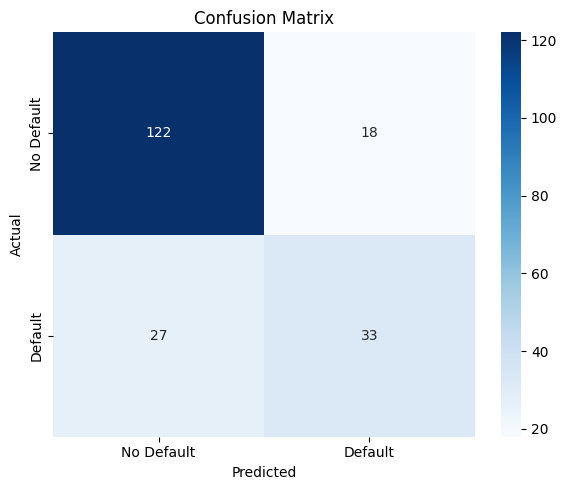

Saved -> models/confusion_matrix.png


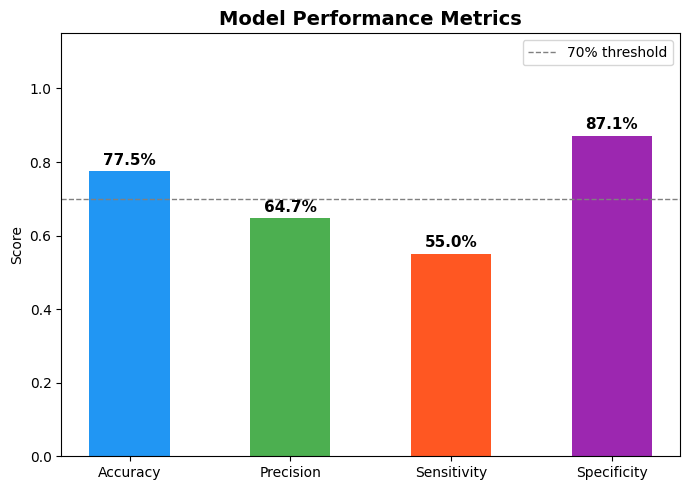

Saved -> models/metrics_chart.png


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

tn, fp, fn, tp = confusion_matrix(Y_test, Y_pred).ravel()
cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
,
cmap="Blues",
xticklabels=["No Default", "Default"],
yticklabels=["No Default", "Default"]
)
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("models/confusion_matrix.png", dpi=150)
plt.show()
print("Saved -> models/confusion_matrix.png")

metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Sensitivity": sensitivity,
    "Specificity": specificity
}

colors = ["#2196F3", "#4CAF50", "#FF5722", "#9C27B0"]
plt.figure(figsize=(7, 5))
bars = plt.bar(metrics.keys(), metrics.values(), color=colors, width=0.5)

for bar, val in zip(bars, metrics.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val*100:.1f}%",
        ha="center", va="bottom", fontweight="bold", fontsize=11
    )
plt.ylim(0, 1.15)
plt.title("Model Performance Metrics", fontsize=14, fontweight="bold")
plt.ylabel("Score")
plt.axhline(y=0.7, color="gray", linestyle="--", linewidth=1, label="70% threshold")
plt.legend()
plt.tight_layout()
plt.savefig("models/metrics_chart.png", dpi=150)
plt.show()
print("Saved -> models/metrics_chart.png")


In [47]:
import pandas as pd
import numpy as np
import pickle

def load_model():
    with open("models/pd_model.pkl", "rb") as f:
        model = pickle.load(f)
    with open("models/scaler.pkl", "rb") as f:
        scaler = pickle.load(f)
    with open("models/feature_names.pkl", "rb") as f:
        features = pickle.load(f)
    return model, scaler, features

def score_single(input_dict: dict, model, scaler, features) -> dict:
    row = pd.DataFrame([input_dict])[features]
    scaled = scaler.transform(row)
    pd_score = float(model.predict_proba(scaled)[0][1])
    bucket = _get_bucket(pd_score)
    priority = _get_priority(pd_score, input_dict.get("DPD", 0),
                            input_dict.get("EMI_Amount", 0))
    return {
        "pd_score": round(pd_score * 100, 2),
        "risk_bucket": bucket,
        "priority": priority,
        "call_action": _get_action(bucket, input_dict.get("Promise_to_Pay", 0)),
    }

def score_portfolio(df: pd.DataFrame, model, scaler, features) -> pd.DataFrame:
    missing = [f for f in features if f not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in uploaded file: {missing}")
    X_scaled = scaler.transform(df[features])
    pd_score = model.predict_proba(X_scaled)[:, 1]
    df = df.copy()
    df["PD_Score_%"] = np.round(pd_score * 100, 2)
    df["Risk Bucket"] = df["PD_Score_%"].apply(lambda s: _get_bucket(s / 100))
    df["Priority_Rank"] = df["PD_Score_%"].rank(ascending=False, method="first").astype(int)
    df["Call_Action"] = df.apply(
        lambda r: _get_action(_get_bucket(r["PD_Score_%"] / 100),
                              r.get("Promise_to_Pay", 0)), axis=1)
    return df.sort_values("Priority_Rank")

def _get_bucket(pd_prob: float) -> str:
    if pd_prob >= 0.75: return "Critical"
    if pd_prob >= 0.50: return "High"
    if pd_prob >= 0.25: return "Medium"
    return "Low"

def _get_priority(pd_prob: float, dpd: int, emi: float) -> str:
    score = pd_prob * 50 + min(dpd / 180, 1) * 30 + min(emi / 45000, 1) * 20
    if score >= 60: return "P1 - Call immediately"
    if score >= 40: return "P2 - Call today"
    if score >= 20: return "P3 - Call this week"
    return "P4 - Low urgency"

def _get_action(bucket: str, promise_to_pay: int) -> str:
    actions = {
        "Critical": "Escalate to senior agent + field visit if PTP broken",
        "High": "Immediate call + send payment link",
        "Medium": "Scheduled callback + NACH re-presentation",
        "Low": "Automated IVR reminder"
    }
    action = actions.get(bucket, "Unknown")
    if promise_to_pay and bucket in ("High", "Critical"):
        action += " | PTP Follow-up"
    return action

In [48]:
import streamlit as st
import pandas as pd
import numpy as np
import os, datetime 
from io import BytesIO
import sys

sys.path.insert(0, os.getcwd())
from utils.scoring_engine import load_model, score_single, score_portfolio

st.set_page_config(
    page_title="COLLECTIONS AGENTIC AI DASHBOARD",
    page_icon="🏦",
    layout="wide",
    initial_sidebar_state="expanded",
)

st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=DM+Sans:wght@300;400;500;600&family=DM+Mono:wght@400;500&display=swap');

html, body, [class*="css"] { font-family: 'DM Sans', sans-serif; }

.header-bar {
    background: linear-gradient(135deg, #1a237e 0%, #283593 60%, #1565c0 100%);
    padding: 1.2rem 2rem;
    border-radius: 12px;
    margin-bottom: 1.5rem;
}
.header-bar h1 { color: white; font-size: 1.4rem; font-weight: 600; margin: 0; }
.header-bar p  { color: rgba(255,255,255,0.75); font-size: 0.8rem; margin: 0; }

.score-card {
    background: white;
    border-radius: 14px;
    padding: 1.6rem;
    text-align: center;
    box-shadow: 0 2px 16px rgba(0,0,0,0.08);
    border-top: 4px solid var(--bucket-color, #1565c0);
}
.score-value {
    font-size: 3.2rem;
    font-weight: 600;
    color: var(--bucket-color, #1565c0);
    font-family: 'DM Mono', monospace;
    line-height: 1;
}
.score-label { font-size: 0.75rem; text-transform: uppercase; letter-spacing: 0.1em; color: #78909c; margin-top: 0.3rem; }

.badge { display: inline-block; padding: 0.3rem 0.9rem; border-radius: 20px; font-size: 0.8rem; font-weight: 500; }
.badge-critical { background: #ffebee; color: #c62828; }
.badge-high     { background: #fff3e0; color: #e65100; }
.badge-medium   { background: #fffde7; color: #f57f17; }
.badge-low      { background: #e8f5e9; color: #2e7d32; }

.action-box {
    background: #f8f9ff;
    border-left: 4px solid #1565c0;
    border-radius: 0 10px 10px 0;
    padding: 1rem 1.2rem;
    font-size: 0.9rem;
    color: #1a237e;
    margin-top: 1rem;
}
.metric-row { display: flex; gap: 12px; margin-bottom: 1rem; }
.metric-mini { flex: 1; background: #f5f7ff; border-radius: 10px; padding: 0.8rem 1rem; text-align: center; }
.metric-mini .val { font-size: 1.5rem; font-weight: 600; color: #1a237e; font-family: 'DM Mono', monospace; }
.metric-mini .lbl { font-size: 0.7rem; color: #78909c; text-transform: uppercase; letter-spacing: 0.08em; }

.section-title {
    font-size: 0.7rem; font-weight: 600; text-transform: uppercase;
    letter-spacing: 0.12em; color: #90a4ae;
    margin: 1.2rem 0 0.5rem; padding-bottom: 0.3rem;
    border-bottom: 1px solid #eceff1;
}
</style>
""", unsafe_allow_html=True)

@st.cache_resource
def get_model():
    try:
        return load_model()
    except FileNotFoundError:
        return None, None, None

model, scaler, features = get_model()

today = datetime.date.today().strftime("%d %b %Y")
st.markdown(f"""
<div class="header-bar">
  <h1>🏦 COLLECTIONS AGENTIC AI DASHBOARD</h1>
  <p>Collections Agent · {today}</p>
</div>
""", unsafe_allow_html=True)

if model is None:
    st.error("Model files not found. Run `python train_model.py` first, then restart.")
    st.code("python generate_data.py\npython train_model.py\nstreamlit run app.py")
    st.stop()

with st.sidebar:
    st.markdown("### Navigation")
    page = st.radio("", [
        "🔍 Score Single Account",
        "📋 Bulk Portfolio Scoring",
        "📊 Portfolio Dashboard",
    ], label_visibility="collapsed")
    st.markdown("---")
    st.success("✅ PD Model loaded")
    st.caption(f"Features: {len(features)}")
    st.markdown("---")
    st.caption("For internal use only.\nDo not share outside DMS.")


if page == "🔍 Score Single Account":
    st.subheader("Score a Single Customer Account")
    st.caption("Enter the customer's details. The model returns a PD score and recommended action instantly.")

    col_left, col_right = st.columns([1.2, 1])

    with col_left:
        with st.form("single_score_form"):
            st.markdown('<div class="section-title">Loan Details</div>', unsafe_allow_html=True)
            c1, c2 = st.columns(2)
            emi_amount   = c1.number_input("EMI Amount (₹)",    min_value=500.0,    max_value=100000.0,  value=8000.0,   step=500.0)
            loan_amount  = c2.number_input("Loan Amount (₹)",   min_value=5000.0,   max_value=2000000.0, value=150000.0, step=5000.0)
            tenure       = c1.number_input("Tenure (months)",   min_value=1,        max_value=120,       value=24)
            credit_score = c2.number_input("Credit Score",      min_value=300,      max_value=900,       value=650)

            st.markdown('<div class="section-title">Delinquency Info</div>', unsafe_allow_html=True)
            c3, c4 = st.columns(2)
            dpd_options = [0] + list(range(1, 31)) + [40, 50, 60, 75, 90, 120, 150, 180]
            dpd          = c3.selectbox("DPD (Days Past Due)", dpd_options)
            bounce_count = c4.number_input("EMI Bounce Count",           min_value=0, max_value=12, value=1)
            last_payment = c3.number_input("Last Payment (days ago)",    min_value=0, max_value=365, value=45)

            st.markdown('<div class="section-title">Contact History</div>', unsafe_allow_html=True)
            c5, c6 = st.columns(2)
            contact_att  = c5.number_input("Contact Attempts",    min_value=0, max_value=20, value=3)
            successful_c = c6.number_input("Successful Contacts", min_value=0, max_value=20, value=1)
            ptp = st.selectbox("Promise to Pay (PTP) Given?", [0, 1],
                                format_func=lambda x: "Yes" if x else "No")

            submitted = st.form_submit_button("▶  Calculate PD Score", use_container_width=True, type="primary")

    with col_right:
        if submitted:
            input_data = {
                "DPD":                   dpd,
                "Bounce_Count":          bounce_count,
                "Contact_Attempts":      contact_att,
                "Successful_Contacts":   min(successful_c, contact_att),
                "Promise_To_Pay":        ptp,
                "Last_Payment_Days_Ago": last_payment,
                "Credit_Score":          credit_score,
                "EMI_Amount":            emi_amount,
                "Loan_Amount":           loan_amount,
                "Tenure_Months":         tenure,
            }
            result  = score_single(input_data, model, scaler, features)
            pd_pct  = result["pd_score"]
            bucket  = result["risk_bucket"]
            priority= result["priority"]
            action  = result["call_action"]

            color_map = {
                "Critical": "#c62828",
                "High":     "#e65100",
                "Medium":   "#f57f17",
                "Low":      "#2e7d32",
            }
            color     = color_map.get(bucket, "#1565c0")
            badge_cls = f"badge-{bucket.lower()}"

            st.markdown(f"""
            <div class="score-card" style="--bucket-color:{color}">
                <div class="score-value">{pd_pct}%</div>
                <div class="score-label">Probability of Default</div>
                <br>
                <span class="badge {badge_cls}">{bucket} Risk</span>
                <br><br>
                <div style="font-size: 0.75rem; color: #78909c; text-transform: uppercase; letter-spacing: 0.1em; margin: 0.5rem 0;">{priority}</div>
            </div>
            """, unsafe_allow_html=True)

            st.markdown(f'<div class="action-box"><strong>Recommended Action</strong><br>{action}</div>', unsafe_allow_html=True)
            st.divider()

            st.markdown("**Score breakdown**")
            breakdown_data = {
                "DPD weight": f"{result['breakdown'].get('dpd_score', 0):.1f} pts",
                "Bounce weight": f"{result['breakdown'].get('bounce_score', 0):.1f} pts",
                "Payment recency": f"{result['breakdown'].get('payment_score', 0):.1f} pts",
                "Credit score": f"{result['breakdown'].get('credit_score', 0):.1f} pts",
                "Contact failure": f"{result['breakdown'].get('contact_score', 0):.1f} pts",
            }
            for key, val in breakdown_data.items():
                st.metric(key, val)


if page == "📋 Bulk Portfolio Scoring":
    st.subheader("Bulk Portfolio Scoring")
    st.caption("Upload your Excel file. Every account gets scored and the result is returned as a ranked call list.")

    uploaded_file = st.file_uploader("Upload Excel file (.xlsx)", type=["xlsx"], label_visibility="collapsed")
    
    if uploaded_file:
        try:
            df = pd.read_excel(uploaded_file)
            results = score_portfolio(df, model, scaler, features)
            
            st.success(f"✅ Scored {len(results)} accounts")
            st.dataframe(results, use_container_width=True, height=400)
            
            csv = results.to_csv(index=False)
            st.download_button(
                label="⬇ Download results as CSV",
                data=csv,
                file_name="portfolio_scores.csv",
                mime="text/csv"
            )
        except Exception as e:
            st.error(f"Error: {str(e)}")
    
    else:
        st.info("📁 Upload an Excel file to begin. Required columns:\n" + 
                ", ".join(features))
        
        if st.button("Load sample dataset (data/loan_accounts.xlsx)"):
            try:
                sample_df = pd.read_excel("data/loan_accounts.xlsx")
                results = score_portfolio(sample_df, model, scaler, features)
                st.success(f"✅ Loaded 1000 sample accounts")
                st.dataframe(results, use_container_width=True, height=400)
                
                csv = results.to_csv(index=False)
                st.download_button(
                    label="⬇ Download sample call list",
                    data=csv,
                    file_name="sample_call_list.csv",
                    mime="text/csv"
                )
            except Exception as e:
                st.error(f"Error loading sample: {str(e)}")


if page == "📊 Portfolio Dashboard":
    st.subheader("Portfolio Risk Dashboard")

    @st.cache_data
    def load_portfolio():
        if os.path.exists("data/loan_accounts.xlsx"):
            df = pd.read_excel("data/loan_accounts.xlsx")
            return score_portfolio(df, model, scaler, features)
        return None

    df_dash = load_portfolio()

    if df_dash is None:
        st.warning("Run notebook cells 13-14 first to generate data and train model.")
    else:
        total    = len(df_dash)
        critical = (df_dash["Risk_Bucket"] == "Critical").sum()
        high     = (df_dash["Risk_Bucket"] == "High").sum()
        avg_pd   = df_dash["PD_Score_%"].mean()
        at_risk_emi = df_dash[df_dash["Risk_Bucket"].isin(["Critical","High"])]["EMI_Amount"].sum()

        k1, k2, k3, k4, k5 = st.columns(5)
        k1.metric("Total Accounts",  f"{total:,}")
        k2.metric("Critical",        f"{critical}")
        k3.metric("High Risk",       f"{high}")
        k4.metric("Avg PD Score",    f"{avg_pd:.1f}%")
        k5.metric("EMI at Risk (₹)", f"₹{at_risk_emi:,.0f}")

        st.markdown("---")
        c1, c2 = st.columns(2)

        with c1:
            st.markdown("**Risk bucket distribution**")
            # support either "Risk_Bucket" or "Risk Bucket"
            if "Risk_Bucket" in df_dash.columns:
                rb_col = "Risk_Bucket"
            elif "Risk Bucket" in df_dash.columns:
                rb_col = "Risk Bucket"
            else:
                st.error("Risk bucket column not found in dataset.")
                rb_col = None

            if rb_col:
                order = ["Critical", "High", "Medium", "Low"]
                bucket_counts = df_dash[rb_col].value_counts().reindex(order, fill_value=0)
                st.bar_chart(pd.DataFrame({"Count": bucket_counts}))

        with c2:
            st.markdown("**PD score distribution**")
            hist_data = pd.cut(df_dash["PD_Score_%"], bins=10).value_counts().sort_index()
            st.bar_chart(pd.DataFrame({"Frequency": hist_data.values}, index=range(len(hist_data))))

        st.markdown("**Average PD score by DPD bucket**")
        df_dash["DPD_Bucket"] = pd.cut(df_dash["DPD"], bins=5)
        dpd_avg = df_dash.groupby("DPD_Bucket", observed=True)["PD_Score_%"].mean()
        st.bar_chart(pd.DataFrame({"Avg PD Score": dpd_avg.values}, index=dpd_avg.index))

        st.markdown("**Top 20 accounts to call today**")
        top20 = df_dash.head(20)[[c for c in ["Priority_Rank","Customer_ID","Loan_Type","EMI_Amount","DPD","PD_Score_%","Risk_Bucket","Call_Action"] if c in df_dash.columns]]
        st.dataframe(top20, use_container_width=True, hide_index=True)
        st.dataframe(
            df_dash[["Priority_Rank", "Customer_ID", "Loan_Type", "EMI_Amount", "PD_Score_%", "Risk_Bucket"]].head(20),
                     use_container_width=True, hide_index=True)

2026-06-15 18:47:14.157 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 18:47:14.159 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 18:47:14.160 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 18:47:14.160 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 18:47:14.162 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 18:47:14.164 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 18:47:14.164 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 18:47:14.166 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar